# GARCH Model

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white", "font.family": "serif", "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.30, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
})

In [2]:
import pandas as pd
import numpy as np
import matplotlib.gridspec as gridspec
import scipy.stats as stats
from scipy.stats import jarque_bera, kstest
import matplotlib.pyplot as plt
from scipy.stats import chi2
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.diagnostic import het_arch
from arch import arch_model

## Data Analysis: A problem with constant volatility

In [3]:
path='/Users/nayelbenabdesadok/GitProjects/Weather Derivatives/data/Henry_Hub_Natural_Gas_Spot_Price.csv'
df_natgas = pd.read_csv(path)
df_natgas['Day'] = pd.to_datetime(df_natgas['Day'])
df_natgas = df_natgas.sort_values(by='Day', ascending=True)
df_natgas = df_natgas.reset_index(drop=True)
df_natgas['t'] = df_natgas.index
df_natgas = df_natgas.rename(columns={"Henry Hub Natural Gas Spot Price Dollars per Million Btu": "price"})
df_natgas.set_index('Day', inplace=True)

df_natgas['return'] = df_natgas['price'].pct_change()

df_natgas['log_return'] = np.log(df_natgas['price'] / df_natgas['price'].shift(1))

df_natgas = df_natgas.dropna(subset=['log_return'])

df_natgas.describe()
df_natgas.to_csv(path)

## Train / Test Split

We estimate the model on the **train set 1997-2016** only. The test set 2017-2026 is left untouched until the final evaluation.

In [4]:
train = df_natgas.loc[:'2016-12-31', 'log_return'].dropna()
test  = df_natgas.loc['2017-01-01':, 'log_return'].dropna()

print(f"Train : {train.index[0].date()} → {train.index[-1].date()} ({len(train)} obs)")
print(f"Test  : {test.index[0].date()}  → {test.index[-1].date()}  ({len(test)} obs)")

Train : 1997-01-10 → 2016-12-30 (5019 obs)
Test  : 2017-01-02  → 2026-04-20  (2330 obs)


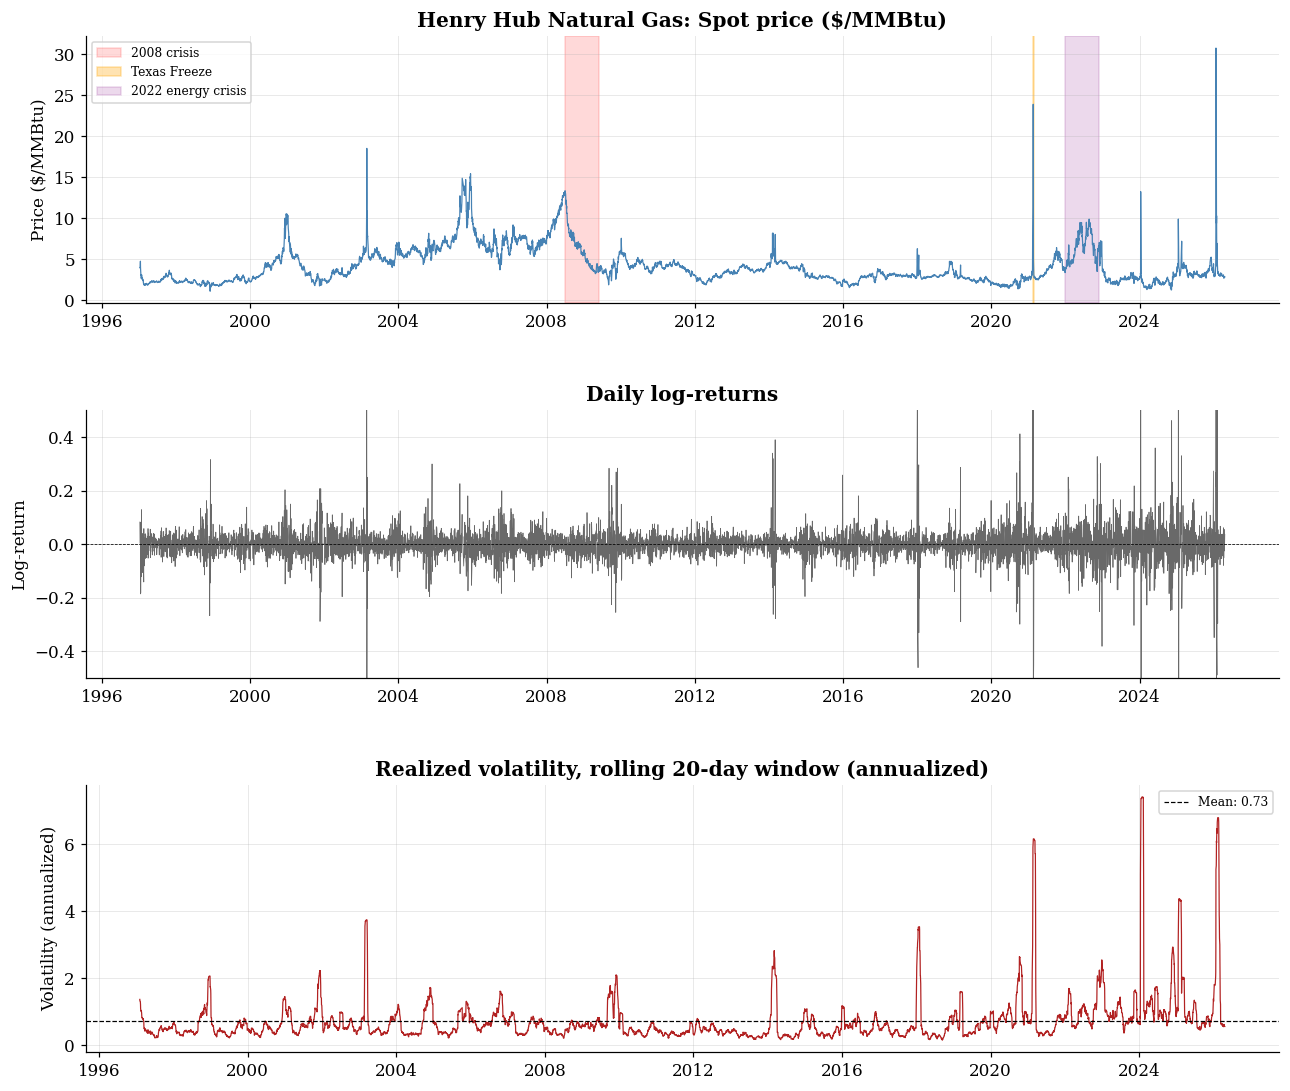

In [5]:
fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(3, 1, hspace=0.4)

# --- Panel 1: spot price ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(df_natgas.index, df_natgas['price'], color='steelblue', linewidth=0.8)
ax1.set_title('Henry Hub Natural Gas: Spot price ($/MMBtu)', fontweight='bold')
ax1.set_ylabel('Price ($/MMBtu)')
ax1.axvspan(pd.Timestamp('2008-07'), pd.Timestamp('2009-06'), alpha=0.15, color='red', label='2008 crisis')
ax1.axvspan(pd.Timestamp('2021-02-10'), pd.Timestamp('2021-02-20'), alpha=0.3, color='orange', label='Texas Freeze')
ax1.axvspan(pd.Timestamp('2022-01'), pd.Timestamp('2022-12'), alpha=0.15, color='purple', label='2022 energy crisis')
ax1.legend(fontsize=8)

# --- Panel 2: log-returns ---
ax2 = fig.add_subplot(gs[1])
ax2.plot(df_natgas.index, df_natgas['log_return'], color='dimgray', linewidth=0.5)
ax2.set_title('Daily log-returns', fontweight='bold')
ax2.set_ylabel('Log-return')
ax2.set_ylim(-0.5, 0.5)

ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')

# --- Panel 3: realized volatility (rolling 20-day) ---

window = 20

df_natgas[f'rv_{window}'] = (
    df_natgas['log_return']
    .rolling(window)
    .std()
    * np.sqrt(252)
)
ax3 = fig.add_subplot(gs[2])
ax3.plot(
    df_natgas.index,
    df_natgas[f'rv_{window}'],
    color='firebrick',
    linewidth=0.8
)
ax3.set_title(
    f'Realized volatility, rolling {window}-day window (annualized)',
    fontweight='bold'
)
ax3.set_ylabel('Volatility (annualized)')
ax3.axhline(
    df_natgas[f'rv_{window}'].mean(),
    color='black',
    linewidth=0.8,
    linestyle='--',
    label=f"Mean: {df_natgas[f'rv_{window}'].mean():.2f}"
)
ax3.legend(fontsize=8)
plt.savefig('natgas_overview.png', dpi=150, bbox_inches='tight')
plt.show()

We notice that risk behaves in volatility clusters: periods of high volatility are followed by periods of high volatility, and vice versa.

To observe the memory of volatility, we analyse the ACF of $|r_t|$. Indeed, under the decomposition $r_t = \sigma_t z_t$ with $z_t \overset{iid}{\sim} N(0,1)$ independent of the past, one shows that:
$$\rho_{|r_t|}(k) \neq 0 \iff \text{Cov}(\sigma_t, \sigma_{t-k}) \neq 0$$

The ACF of $|r_t|$ is therefore non-zero if and only if $\sigma_t$ is autocorrelated. Observing a persistent ACF of $|r_t|$ is the direct empirical justification for modelling $\sigma_t^2$ as depending on the past.

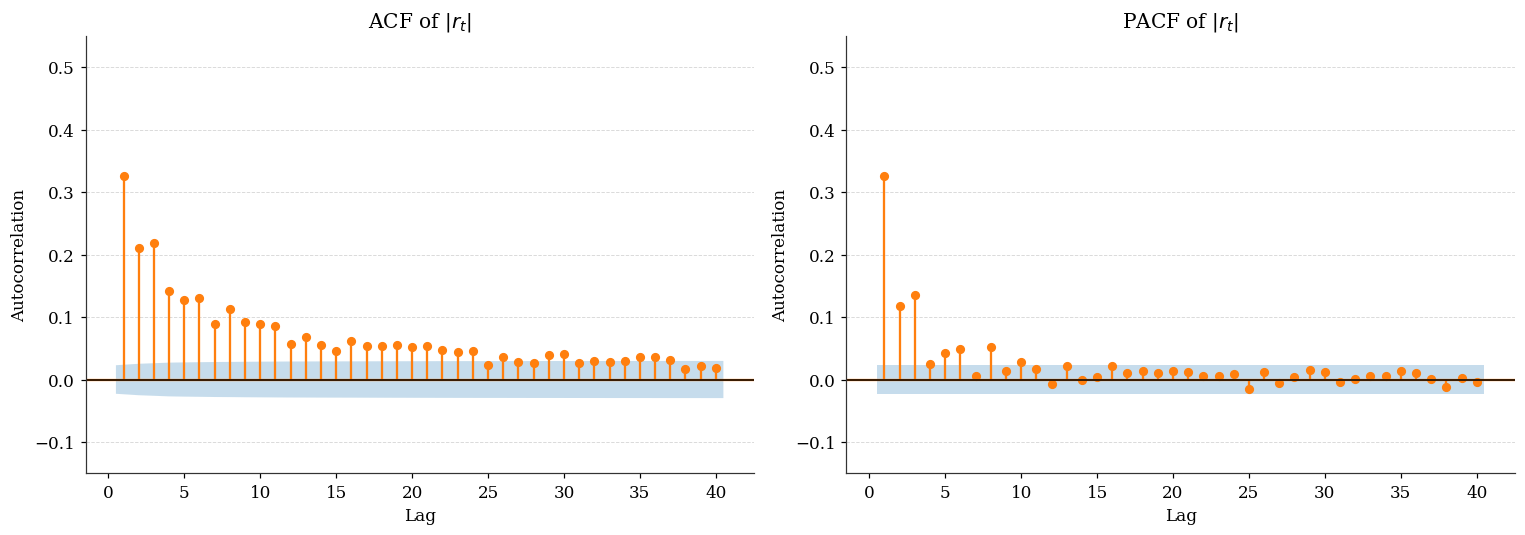

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
abs_lr = df_natgas['return'].abs()
col_abs = 'tab:orange'

plot_acf(abs_lr, lags=40, ax=axes[0], color=col_abs,
         vlines_kwargs={'colors': col_abs, 'linewidth': 1.5},
         title=r'ACF of $|r_t|$', zero=False, alpha=0.05)

plot_pacf(abs_lr, lags=40, ax=axes[1], color=col_abs,
          vlines_kwargs={'colors': col_abs, 'linewidth': 1.5},
          title=r'PACF of $|r_t|$', zero=False, alpha=0.05)

for ax in axes:
    ax.set_ylim(-0.15, 0.55)
    ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.3)
    ax.xaxis.grid(False)
    ax.axhline(0, color='black', linewidth=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')

plt.tight_layout()
plt.savefig('natgas_acf_absrt.png', dpi=300, bbox_inches='tight')
plt.show()

The ACF clearly shows that past risk has a significant impact on current risk: past shocks influence future shocks.

We can finally inspect the distribution of the log-returns with a QQ-plot to compare it with a normal distribution.

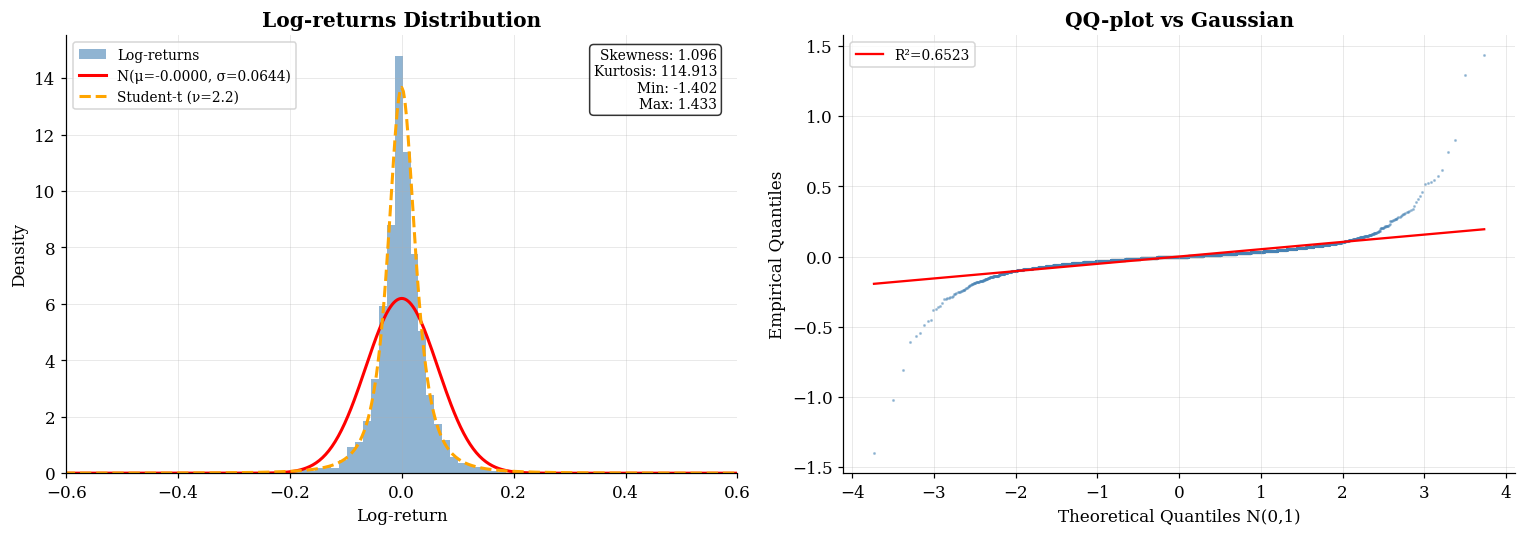

  Jarque-Bera stat    :   4039421.94
  Jarque-Bera p-value :     0.00e+00
  KS stat (vs Normal) :       0.1412
  KS p-value          :    2.97e-128
  Excess Kurtosis     :      114.913
  Skewness            :        1.096
  Fitted Student-t ν  :         2.23


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lr = df_natgas['log_return'].dropna()

ax1 = axes[0]
ax1.hist(lr, bins=200, density=True, color='steelblue', alpha=0.6, label='Log-returns')

x = np.linspace(lr.min(), lr.max(), 1000)

mu, sigma = lr.mean(), lr.std()
ax1.plot(x, stats.norm.pdf(x, mu, sigma), 
         color='red', linewidth=2, label=f'N(μ={mu:.4f}, σ={sigma:.4f})')

nu, loc, scale = stats.t.fit(lr)
ax1.plot(x, stats.t.pdf(x, nu, loc, scale), 
         color='orange', linewidth=2, linestyle='--', label=f'Student-t (ν={nu:.1f})')

ax1.set_xlim(-0.6, 0.6)
ax1.set_title('Log-returns Distribution', fontweight='bold')
ax1.set_xlabel('Log-return')
ax1.set_ylabel('Density')
ax1.legend(fontsize=9)

textstr = '\n'.join([
    f'Skewness: {lr.skew():.3f}',
    f'Kurtosis: {lr.kurtosis():.3f}', 
    f'Min: {lr.min():.3f}',
    f'Max: {lr.max():.3f}',
])
ax1.text(0.97, 0.97, textstr, transform=ax1.transAxes,
         fontsize=9, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax2 = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(lr, dist='norm')
ax2.scatter(osm, osr, s=1, color='steelblue', alpha=0.4)
ax2.plot(osm, slope * np.array(osm) + intercept, 
         color='red', linewidth=1.5, label=f'R²={r**2:.4f}')
ax2.set_title('QQ-plot vs Gaussian', fontweight='bold')
ax2.set_xlabel('Theoretical Quantiles N(0,1)')
ax2.set_ylabel('Empirical Quantiles')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('natgas_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

jb_stat, jb_p = jarque_bera(lr)
ks_stat, ks_p = kstest(lr, 'norm', args=(mu, sigma))

print(f"{'='*45}")
print(f"  Jarque-Bera stat    : {jb_stat:>12.2f}")
print(f"  Jarque-Bera p-value : {jb_p:>12.2e}")
print(f"  KS stat (vs Normal) : {ks_stat:>12.4f}")
print(f"  KS p-value          : {ks_p:>12.2e}")
print(f"  Excess Kurtosis     : {lr.kurtosis():>12.3f}")
print(f"  Skewness            : {lr.skew():>12.3f}")
print(f"  Fitted Student-t ν  : {nu:>12.2f}")
print(f"{'='*45}")

We clearly see that the returns distribution is not normal, with much fatter tails marked by extreme events that are far more likely to occur, and even asymmetric in our case (positive skew). The log-returns law resembles a Student-t distribution with $\nu = 2.24$ degrees of freedom.

The constant-volatility model underestimates all these extreme events, which are far more likely to occur, whereas the market has seen them happen repeatedly (2008, Texas Freeze, energy crisis).

## The GARCH Model

The GARCH model is an extension of the ARCH model, which stated that volatility depends on the shocks of the previous period $\sigma_{t}^2 = \omega + \alpha \epsilon_{t-1}^2$ with $r_t = \mu + \epsilon_t$. Here, $\mu_t = \mathbb{E}[r_t | \mathcal{F}_{t-1}]$ is the best prediction of $r_t$ given the past, and $\epsilon_t$ represents what cannot be predicted. We can run a hypothesis test on $\mu$. Do we have $H_0 : \mu_t=0$?

In [8]:
returns = df_natgas['log_return'].dropna()
# Student t-test, H0: mu = 0
t_stat, p_value = stats.ttest_1samp(returns, popmean=0)

n    = len(returns)
mu   = returns.mean()
se   = lr.std() / np.sqrt(n)
ci_low  = mu - 1.96 * se
ci_high = mu + 1.96 * se

print(f"{'='*45}")
print(f"  t-test, H0: μ = 0")
print(f"{'='*45}")
print(f"  n          : {n}")
print(f"  μ̂          : {mu:.6f}")
print(f"  Std error  : {se:.6f}")
print(f"  t-stat     : {t_stat:.4f}")
print(f"  p-value    : {p_value:.4f}")
print(f"  CI 95%     : [{ci_low:.6f}, {ci_high:.6f}]")
print(f"{'='*45}")
print(f"  H0 rejected: {'Yes' if p_value < 0.05 else 'No'}")
print(f"{'='*45}")

  t-test, H0: μ = 0
  n          : 7349
  μ̂          : -0.000034
  Std error  : 0.000751
  t-stat     : -0.0454
  p-value    : 0.9638
  CI 95%     : [-0.001507, 0.001438]
  H0 rejected: No


Hence $r_t = \epsilon_t$ in our case.

Here, in the GARCH model, volatility also depends on the shocks of previous periods: $$\sigma_{t}^2 = \omega + \alpha r_{t-1}^2 + \beta \sigma_{t-1}^2$$ where:
- $\omega$ is the unconditional variance, the market's minimal volatility
- $\alpha$ measures the impact of the previous period's shocks
- $\beta$ measures the impact of the previous period's volatility

The whole temporal structure of $r_t$ is captured by $\sigma_t^2$. In our case, $z_t = r_t / \sigma_t$ should no longer contain any temporal structure, i.e. it should be white noise (no autocorrelation).

In [9]:
# ============================================================
# ESTIMATION: GARCH(1,1) Student-t (selected model)
# ============================================================
res = arch_model(
    train * 100,
    mean='Zero',
    vol='GARCH',
    p=1, q=1,
    dist='studentst'
).fit(disp='off')

omega = res.params['omega']
alpha = res.params['alpha[1]']
beta  = res.params['beta[1]']
nu    = res.params['nu']

print(res.summary())
print(f"\n{'='*45}")
print(f"  omega          : {omega:.4f}")
print(f"  alpha          : {alpha:.4f}")
print(f"  beta           : {beta:.4f}")
print(f"  nu             : {nu:.4f}")
print(f"  alpha + beta   : {alpha + beta:.4f}")
print(f"  long-term sigma: {np.sqrt(omega/(1-alpha-beta))/100*np.sqrt(252):.2f} (annualized)")
print(f"  Half-life      : {np.log(0.5)/np.log(alpha+beta):.1f} days")
print(f"{'='*45}")

                          Zero Mean - GARCH Model Results                           
Dep. Variable:                   log_return   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -13310.1
Distribution:      Standardized Student's t   AIC:                           26628.1
Method:                  Maximum Likelihood   BIC:                           26654.2
                                              No. Observations:                 5019
Date:                      Mon, Jul 06 2026   Df Residuals:                     5019
Time:                              23:03:28   Df Model:                            0
                            Volatility Model                            
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega          0

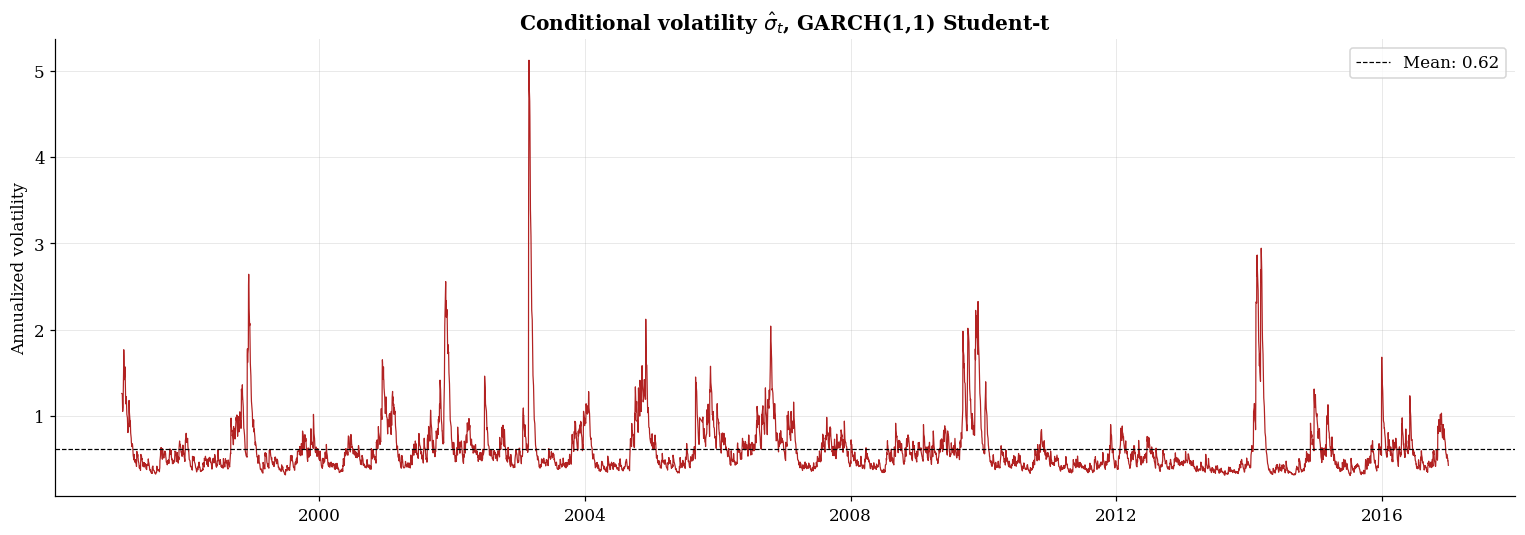

In [10]:
sigma_t = res.conditional_volatility / 100
# Annualised
sigma_t_ann = sigma_t * np.sqrt(252)
# Visualization
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, sigma_t_ann, color='firebrick', lw=0.8)
ax.axhline(sigma_t_ann.mean(), color='black', lw=0.8, ls='--',
           label=f'Mean: {sigma_t_ann.mean():.2f}')
ax.set_title('Conditional volatility $\\hat{\\sigma}_t$, GARCH(1,1) Student-t',
             fontweight='bold')
ax.set_ylabel('Annualized volatility')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

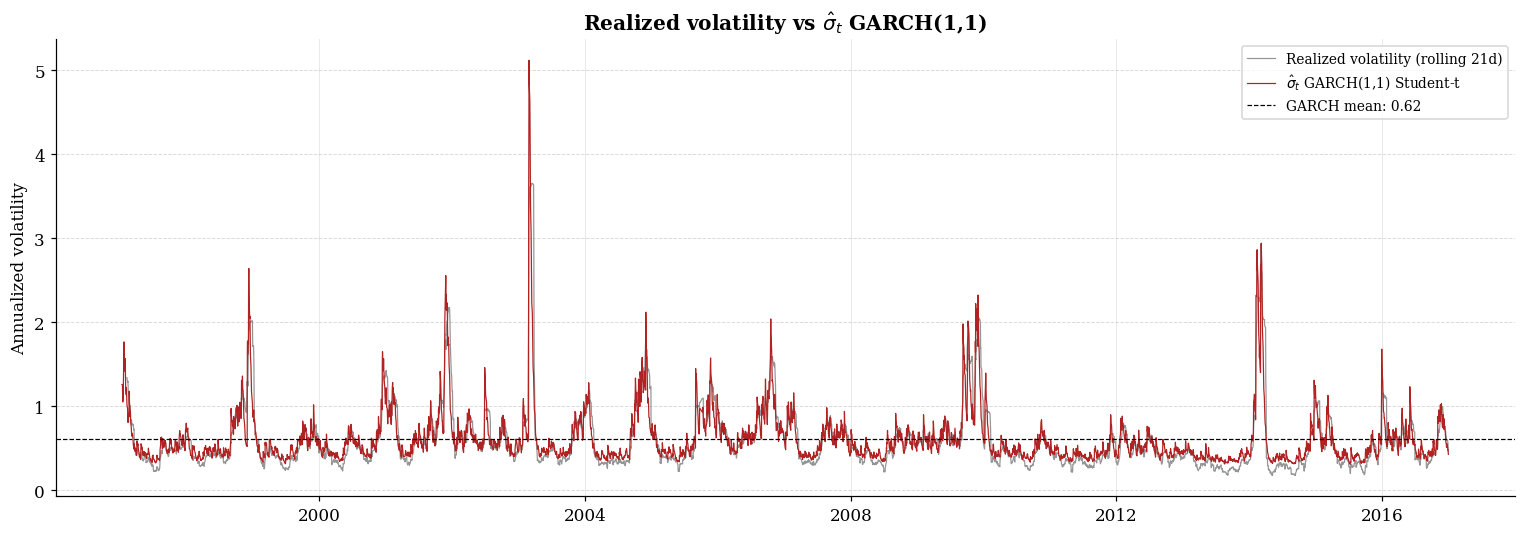

In [11]:
# Realized volatility, rolling 21-day window (proxy for true volatility)
rv_21 = train.rolling(21).std() * np.sqrt(252)

# GARCH conditional volatility, annualized
sigma_t_ann = res.conditional_volatility / 100 * np.sqrt(252)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train.index, rv_21, color='dimgray', lw=0.8, alpha=0.7,
        label='Realized volatility (rolling 21d)')
ax.plot(train.index, sigma_t_ann, color='firebrick', lw=0.8,
        label='$\\hat{\\sigma}_t$ GARCH(1,1) Student-t')

ax.axhline(sigma_t_ann.mean(), color='black', lw=0.8, ls='--',
           label=f'GARCH mean: {sigma_t_ann.mean():.2f}')

ax.set_title('Realized volatility vs $\\hat{\\sigma}_t$ GARCH(1,1)',
             fontweight='bold')
ax.set_ylabel('Annualized volatility')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# MODEL 1: GARCH(1,1) Gaussian
# ============================================================
res_gauss = arch_model(
    train * 100,
    mean='Zero',
    vol='GARCH',
    p=1, q=1,
    dist='normal'
).fit(disp='off')

# ============================================================
# MODEL 2: GARCH(1,1) Student-t
# ============================================================
res_stud = arch_model(
    train * 100,
    mean='Zero',
    vol='GARCH',
    p=1, q=1,
    dist='studentst'
).fit(disp='off')

# ============================================================
# ν ON ẑ_t AFTER STUDENT GARCH
# ============================================================
zt = res_stud.std_resid.dropna()
nu_zt, _, _ = stats.t.fit(zt)

# ============================================================
# LR TEST
# ============================================================
LR    = 2 * (res_stud.loglikelihood - res_gauss.loglikelihood)
p_val = 1 - chi2.cdf(LR, df=1)

print(f"{'='*50}")
print(f"  JUSTIFICATION FOR THE STUDENT-t CHOICE")
print(f"{'='*50}")
print(f"\n  1. Fat tails on ẑ_t after GARCH")
print(f"     ν fitted on ẑ_t: {nu_zt:.2f}")
print(f"     → tails persist after removing σ_t")
print(f"\n  2. Likelihood-ratio test")
print(f"     H0 : z_t ~ N(0,1)")
print(f"     H1 : z_t ~ Student-t_ν")
print(f"     LogL Gaussian  : {res_gauss.loglikelihood:.2f}")
print(f"     LogL Student-t : {res_stud.loglikelihood:.2f}")
print(f"     LR stat        : {LR:.2f}")
print(f"     χ²(1) at 5%    : {chi2.ppf(0.95, df=1):.2f}")
print(f"     p-value        : {p_val:.2e}")
print(f"     Decision       : {'H0 rejected ✗ → Student-t selected' if p_val < 0.05 else 'H0 not rejected'}")
print(f"{'='*50}")

  JUSTIFICATION FOR THE STUDENT-t CHOICE

  1. Fat tails on ẑ_t after GARCH
     ν fitted on ẑ_t: 5.59
     → tails persist after removing σ_t

  2. Likelihood-ratio test
     H0 : z_t ~ N(0,1)
     H1 : z_t ~ Student-t_ν
     LogL Gaussian  : -13539.44
     LogL Student-t : -13310.05
     LR stat        : 458.77
     χ²(1) at 5%    : 3.84
     p-value        : 0.00e+00
     Decision       : H0 rejected ✗ → Student-t selected


## Diagnostics: $\hat{z}_t = r_t / \hat{\sigma}_t$

If the GARCH is well specified, $\hat{z}_t$ must be white noise: the whole temporal structure of $r_t$ has been absorbed by $\hat{\sigma}_t^2$.

We test:
- **LB on $\hat{z}_t$**: no autocorrelation in mean
- **LB on $\hat{z}_t^2$**: no residual ARCH effects
- **Engle LM on $\hat{z}_t$**: variance well captured

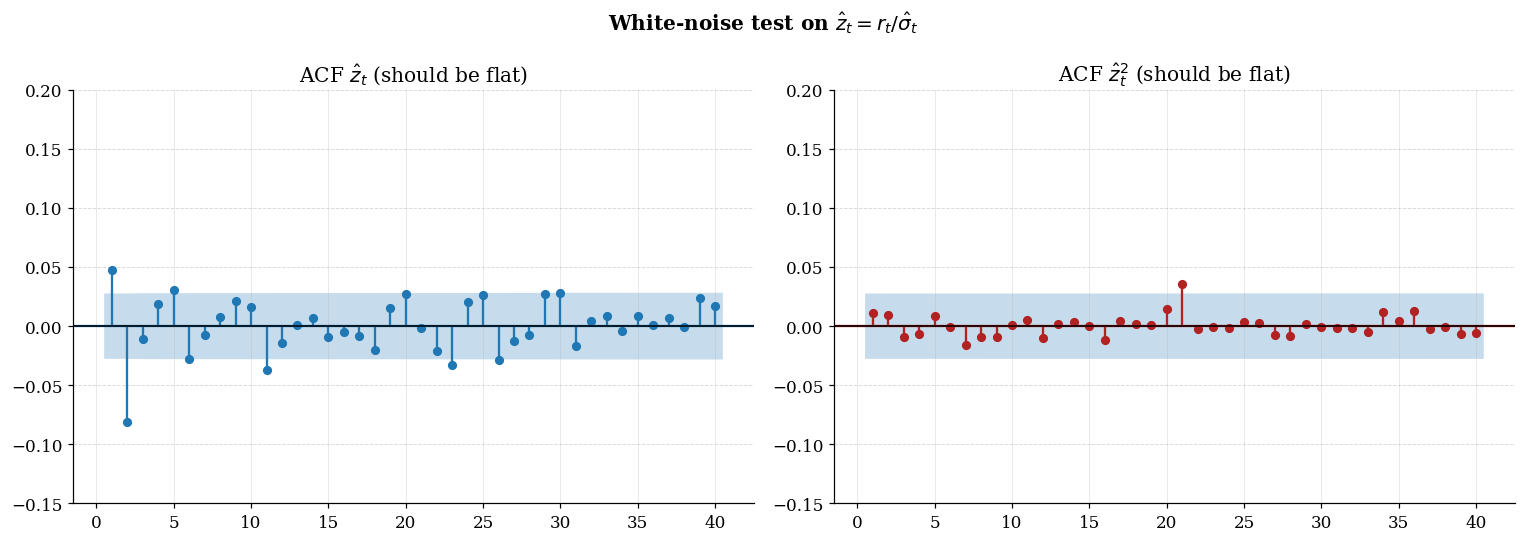

  LB ẑ_t   (H0: white noise in mean)
       lb_pvalue
5   8.140249e-10
10  5.187061e-09
20  2.524997e-08

  LB ẑ_t²  (H0: no residual ARCH effects)
    lb_pvalue
5    0.830835
10   0.936847
20   0.997392

  Engle LM, p: 0.941

  Variance verdict: ✓ well captured


In [13]:
zt = res.std_resid.dropna()

# --- ACF ẑ_t et ẑ_t² ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(zt, lags=40, ax=axes[0], zero=False, alpha=0.05,
         title=r'ACF $\hat{z}_t$ (should be flat)')
plot_acf(zt**2, lags=40, ax=axes[1], zero=False, alpha=0.05,
         color='firebrick',
         vlines_kwargs={'colors': 'firebrick'},
         title=r'ACF $\hat{z}_t^2$ (should be flat)')

for ax in axes:
    ax.set_ylim(-0.15, 0.20)
    ax.axhline(0, color='black', lw=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.3)

plt.suptitle(r'White-noise test on $\hat{z}_t = r_t / \hat{\sigma}_t$',
             fontweight='bold')
plt.tight_layout()
plt.show()

# --- Tests formels ---
lb_zt  = acorr_ljungbox(zt,    lags=[5, 10, 20], return_df=True)
lb_zt2 = acorr_ljungbox(zt**2, lags=[5, 10, 20], return_df=True)
lm_stat, lm_p, _, _ = het_arch(zt, nlags=10)

print(f"{'='*50}")
print(f"  LB ẑ_t   (H0: white noise in mean)")
print(lb_zt[['lb_pvalue']].to_string())
print(f"\n  LB ẑ_t²  (H0: no residual ARCH effects)")
print(lb_zt2[['lb_pvalue']].to_string())
print(f"\n  Engle LM, p: {lm_p:.3f}")
print(f"{'='*50}")
print(f"\n  Variance verdict: {'✓ well captured' if lm_p > 0.05 else '✗ residual ARCH effects'}")

## Conclusion: Toward the coupling

The Student-t GARCH(1,1) captures the **endogenous dynamics** of $\sigma_t^2$ well:
- $\alpha + \beta \approx 0.97$: high persistence, half-life ~24 days
- LB on $\hat{z}_t^2$ and Engle LM not rejected: no residual ARCH effects
- $\hat{\nu} = 5.58$: fat tails well modelled

**Identified limitation:** the winter seasonality of volatility remains unexplained by $(\omega, \alpha, \beta)$. The GARCH absorbs the clustering but not the meteorological structure.

$\Rightarrow$ The next step is to add $\gamma \cdot \tilde{HDD}_{t-1}^+$ in the variance equation to formally test the temperature-volatility coupling.